In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.patches as patches
import matplotlib.cm as cm
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
# import matplotlib.colors as colors
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

In [2]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

In [3]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

## (a) Land Cover

In [61]:
# --- input Plant Function Type 
# read data
file_veg = './Fig1_PFT.nc'
ds_veg = xr.open_dataset(file_veg)

# read variable: PCT_PFT
pft_Pi = ds_veg['PFT_Pi']
pft_Mio = ds_veg['PFT_Mio']

# --- input Plant Function Type 
# read data
file_ice = './Fig1_LandIce.nc'
ds_ice = xr.open_dataset(file_ice)

# read variable: LandIce
ice_Pi = ds_ice['LandIce_Pi']
ice_Mio = ds_ice['LandIce_Mio']


# --- compile the dataset
PFT_Pi = np.empty((18, lat.size, lon.size))
PFT_Pi = xr.DataArray(data=PFT_Pi, dims=['LandCover','lat','lon'], coords=[np.arange(1,18.5,1), lat, lon])
PFT_Mio = np.empty((18, lat.size, lon.size))
PFT_Mio = xr.DataArray(data=PFT_Mio, dims=['LandCover','lat','lon'], coords=[np.arange(1,18.5,1), lat, lon])

PFT_Pi[0:17,:,:] = pft_Pi
PFT_Pi[17,:,:] = ice_Pi
PFT_Mio[0:17,:,:] = pft_Mio
PFT_Mio[17,:,:] = ice_Mio

PFT_Pi = xr.DataArray(data=PFT_Pi, dims=['lsmpft','lat','lon'], coords=[np.arange(1,19,1), lat, lon])
PFT_Mio = xr.DataArray(data=PFT_Mio, dims=['lsmpft','lat','lon'], coords=[np.arange(1,19,1), lat, lon])

In [62]:
plant_type = ['Bare','NL evergreen temperate','NL evergreen boreal','NL deciduous boreal',
              'BL evergreen tropical','BL evergreen temperate','BL deciduous tropical','BL deciduous temperate',
              'BL deciduous boreal','BL evergreen shrub','BL deciduous temperate shrub','BL deciduous boreal shrub',
              'arctic C3 grass','non-arctic C3 grass','C4 grass','corn','wheat','Land Ice']

# Add cyclic point to mask
PFT_Pi, lons_veg = add_cyclic_point(PFT_Pi, coord=lon)
PFT_Mio, lons_veg = add_cyclic_point(PFT_Mio, coord=lon)

In [63]:
# --- Preindustrial: dominant PFT ---
Dom_pft_Pi = PFT_Pi[0,:,:].copy()

for yy in range(lat.size):
    for xx in range(lons_veg.size):
        dominant_pft = np.argmax(PFT_Pi[:, yy, xx])
        Dom_pft_Pi[yy,xx] = dominant_pft

# --- Miocene: dominant PFT ---
Dom_pft_Mio = PFT_Mio[0,:,:].copy()

for yy in range(lat.size):
    for xx in range(lons_veg.size):
        dominant_pft = np.argmax(PFT_Mio[:, yy, xx])
        Dom_pft_Mio[yy,xx] = dominant_pft

Text(0.5, 0.66, 'Dominant Plant type')

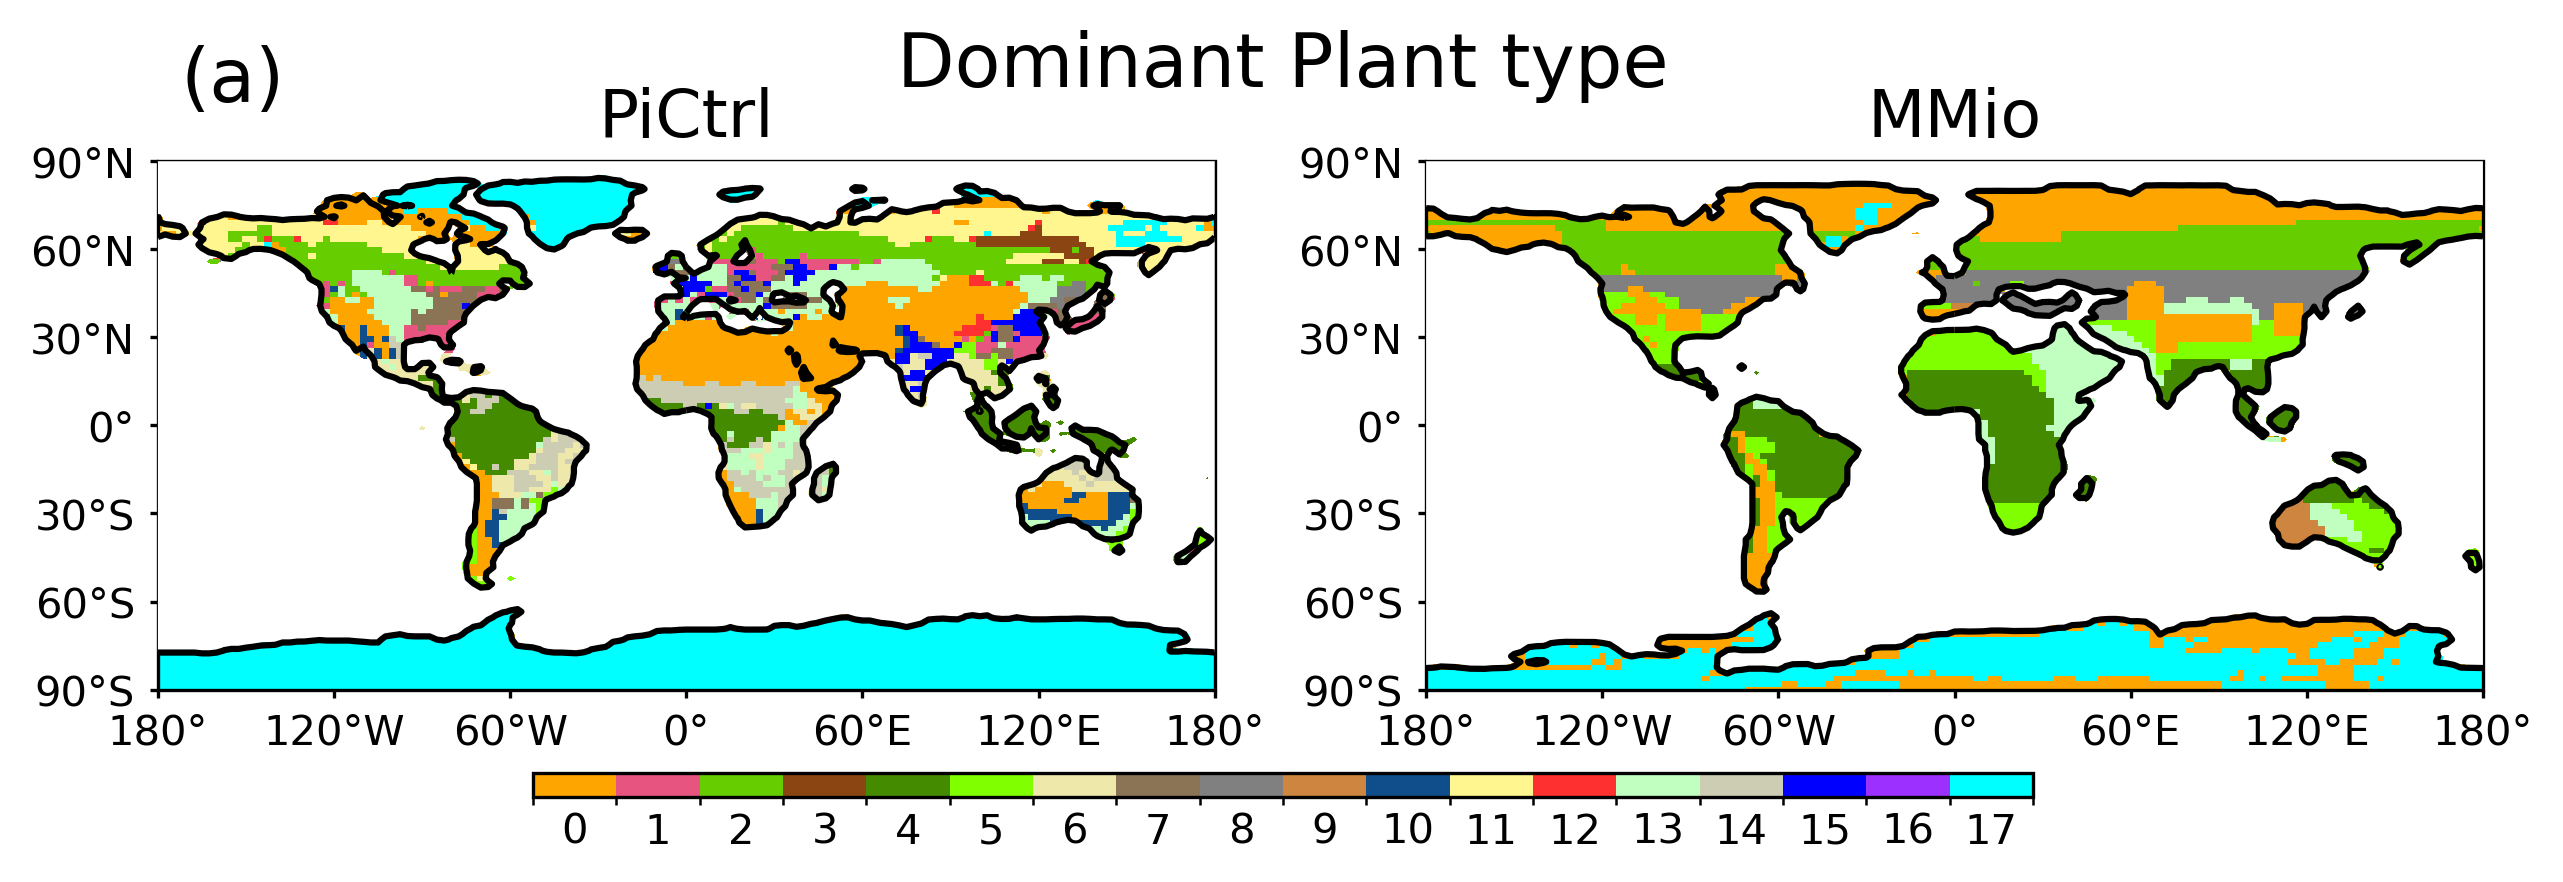

In [64]:
# Create 18 discrete colors

colors = [
    "#ffa500", "#e75480", "#66cd00", "#8b4513", "#458b00", "#7fff00",
    "#eee8aa", "#8b7355", "#808080", "#cd853f", "#104e8b", "#fff68f",
    "#ff3030", "#c1ffc1", "#cdcdb4", "#0000ff", "#9b30ff", "cyan"]
cmap = mcolors.ListedColormap(colors)

# Create a mappable object for the colorbar
norm = mcolors.BoundaryNorm(boundaries=np.arange(19)-0.5, ncolors=18)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


# -----------------------------------------------------------
# Function of Plotting

data_title = 'Dominant Plant type'
plot_name = 'Fig1a_dominant_plant_type'
levels = np.arange(0,18.5,1)          # manually set the levels we want to see here

fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                        figsize=(10,8), dpi=300)


# -------------------------------------------------------------------
# Contour plot --- Pre-industrial Veg

# Pre-industrial Veg
cs = axs[0].pcolormesh(lons_veg, lat, Dom_pft_Pi, cmap=cmap, norm=norm,
                       transform=ccrs.PlateCarree(),
                       shading='nearest', zorder=1)           # 'nearest' avoids edge interpolation

# Mask (white areas)
axs[0].contourf(lons_veg, lat, mask_Pi, [-0.1,0.1],
                transform = ccrs.PlateCarree(),
                linestyles='solid', colors='white', zorder=3)

# Optional black contour line around mask
axs[0].contour(lons_veg, lat, mask_Pi, [0.3,1.8],
               transform=ccrs.PlateCarree(),
               linestyles='solid', linewidths=1.5, colors='k', zorder=4)


# Longitude labels
axs[0].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()  
axs[0].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
axs[0].tick_params(axis='x', size=2)             # set xtick parameters
for xlabel in axs[0].get_xticklabels():          # set xticks_label
    xlabel.set_fontsize(10)        

# Latitude labels
axs[0].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
axs[0].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
axs[0].tick_params(axis='y', size=2)             # set ytick parameters
for ylabel in axs[0].get_yticklabels():          # set yticks_label
    ylabel.set_fontsize(10)        
    
# Title each subplot with the name of the month
axs[0].set_title('PiCtrl', fontsize=16)


# -------------------------------------------------------------------
# Contour plot --- Miocene Veg

# Miocene Veg
cs = axs[1].pcolormesh(lons_veg, lat, Dom_pft_Mio, cmap=cmap, norm=norm,
                       transform=ccrs.PlateCarree(), shading='nearest', zorder=2)

# Mask (white areas)
axs[1].contourf(lons_veg, lat, mask_Mio, [-0.1,0.1], transform = ccrs.PlateCarree(),
                linestyles='solid', colors='white', zorder=3)

# Optional black contour line around mask
axs[1].contour(lons_veg, lat, mask_Mio, [0.3,1.8], transform=ccrs.PlateCarree(),
               linestyles='solid', linewidths=1.5, colors='k', zorder=4)


# Longitude labels
axs[1].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()  
axs[1].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
axs[1].tick_params(axis='x', size=2)             # set xtick parameters
for xlabel in axs[1].get_xticklabels():          # set xticks_label
    xlabel.set_fontsize(10)        

# Latitude labels
axs[1].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
axs[1].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
axs[1].tick_params(axis='y', size=2)             # set ytick parameters
for ylabel in axs[1].get_yticklabels():          # set yticks_label
    ylabel.set_fontsize(10)        
    
# Title each subplot with the name of the month
axs[1].set_title('MMio', fontsize=16)


# -------------------------------------------------------------------

cax = fig.add_axes([0.25, 0.34, 0.5, 0.01]) 
CB = plt.colorbar(sm, cax=cax, orientation='horizontal', ticks=np.arange(18))
CB.ax.set_xticklabels([str(i) for i in range(18)])
CB.outline.set_visible(True)
CB.ax.tick_params(size=0)         # optional: remove tick marks

plt.figtext(0.15,0.63,'(a)',ha='center',fontsize=18)

# Add title
plt.suptitle(data_title, y=0.66, fontsize=18)
# fig.savefig(plot_name+'.png')

## (b) Soil Erodibility Factor

In [45]:
# read data
file_S_Pi = './dst_1.9x2.5_c090203.nc'
file_S_Mio = './dst_1.9x2.5_c090203_MMIO_012023.nc'
ds_S_Pi = xr.open_dataset(file_S_Pi)
ds_S_Mio = xr.open_dataset(file_S_Mio)

# read variable
SEF_Pi = ds_S_Pi['mbl_bsn_fct_geo']*100
SEF_Mio = ds_S_Mio['mbl_bsn_fct_geo']*100

In [46]:
# Add cyclic point to mask
SEF_Pi, lons = add_cyclic_point(SEF_Pi, coord=lon)
SEF_Mio, lons = add_cyclic_point(SEF_Mio, coord=lon)

/glade/derecho/scratch/pjchen/tmp/ipykernel_54629/229230998.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('YlOrRd',len(levels))


Text(0.5, 0.65, 'Soil Erodibility Factor')

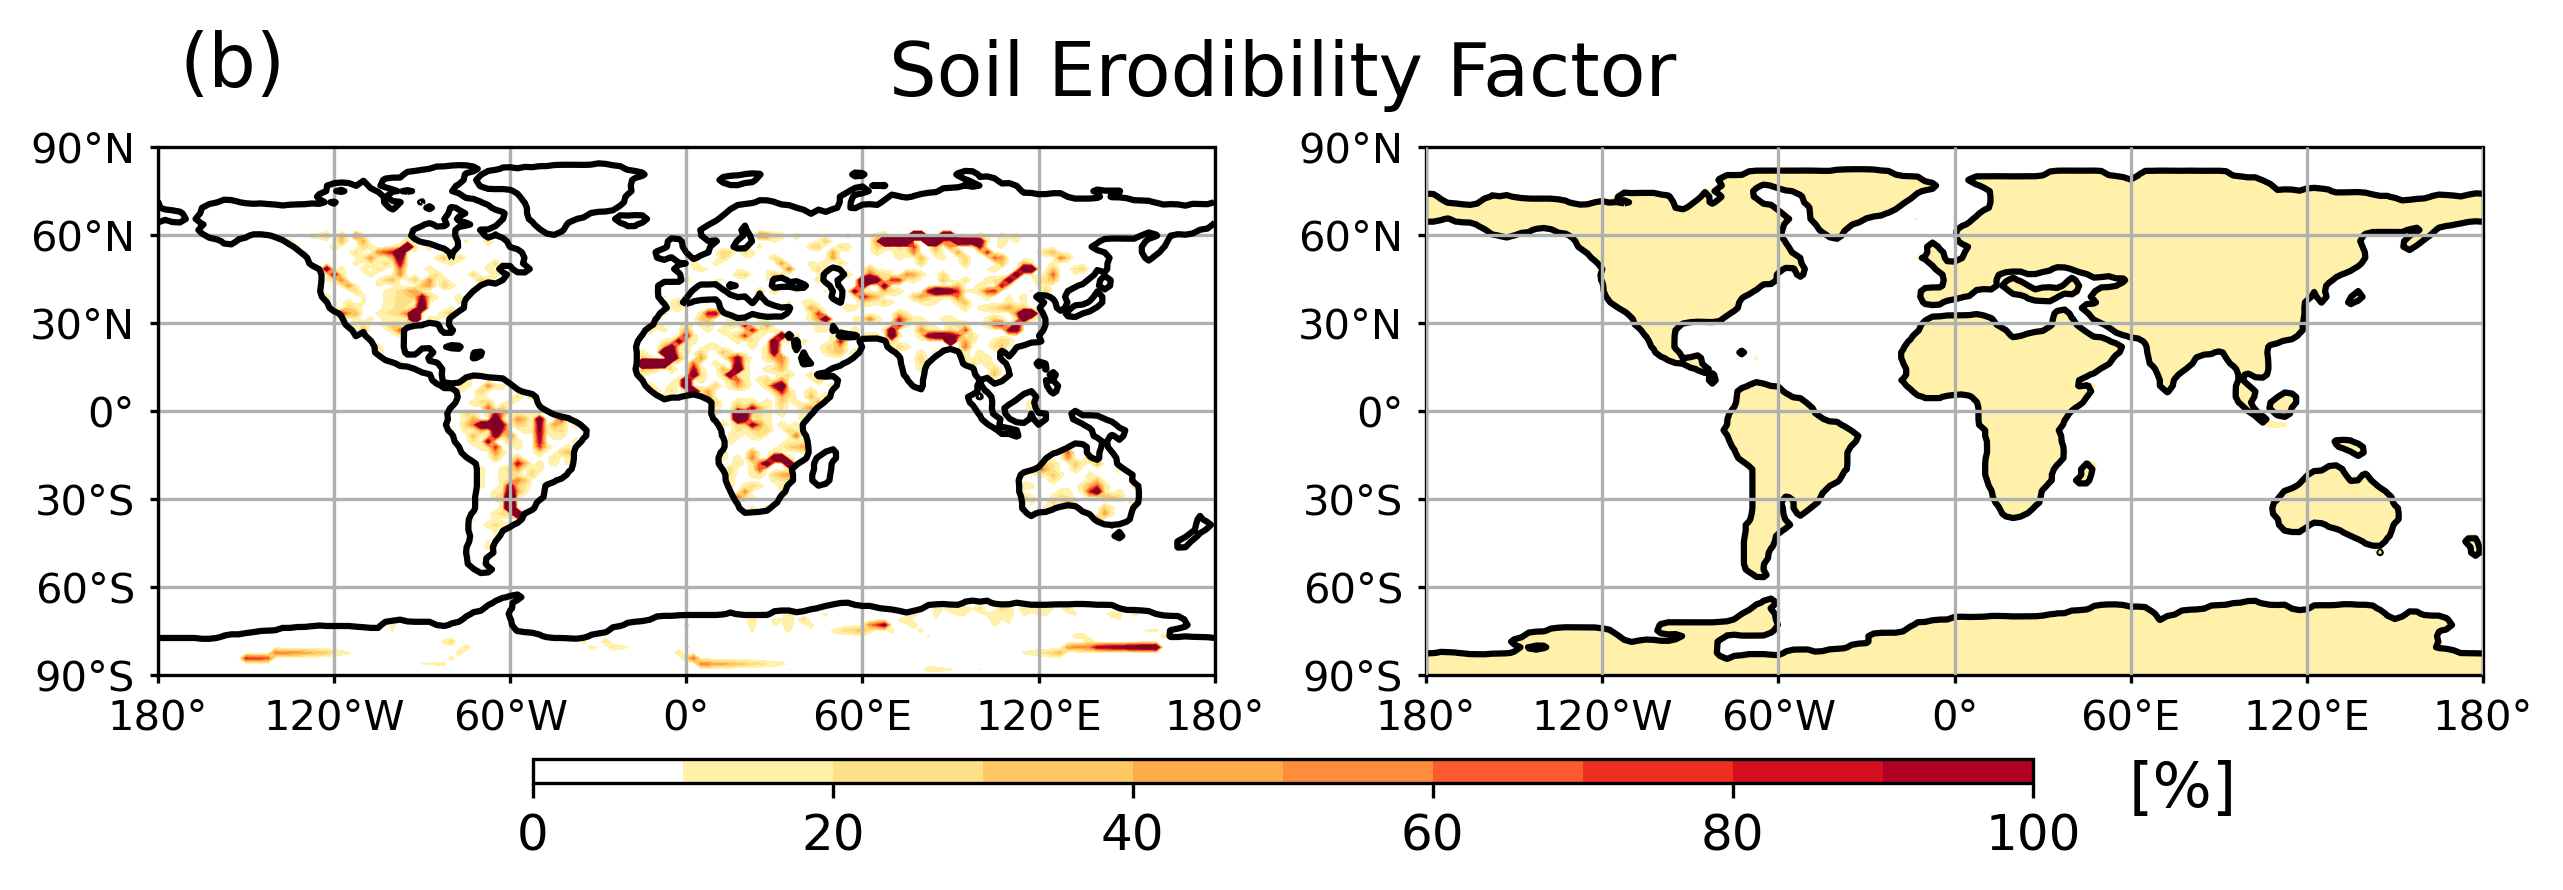

In [47]:
# Function of Plotting

data_title = 'Soil Erodibility Factor'
plot_name = 'Fig1b_soil_erodibility_factor'
levels = np.arange(0,101,10)          # manually set the levels we want to see here

fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                        figsize=(10,8), dpi=300)

cmap = plt.cm.get_cmap('YlOrRd',len(levels))
colors = list(cmap(np.arange(len(levels))))
colors[0] = "white"                                # replace first color with white
cmap = mcolors.ListedColormap(colors[:-1], "")
cmap.set_over(colors[-1])                          # set over-color to last color of list 

# ======================================================================================
# Contour plot --- Pi Simulation
cs=axs[0].contourf(lons, lat, SEF_Pi, levels = levels, transform = ccrs.PlateCarree(),
                   cmap=cmap, extend='max')

# Longitude labels
axs[0].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()  
axs[0].xaxis.set_major_formatter(lon_formatter)   # set the format of xticks_label
axs[0].tick_params(axis='x', size=2)              # set xtick parameters
for xlabel in axs[0].get_xticklabels():           # set xticks_label
    xlabel.set_fontsize(10)        

# Latitude labels
axs[0].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
axs[0].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
axs[0].tick_params(axis='y', size=2)             # set ytick parameters
for ylabel in axs[0].get_yticklabels():          # set yticks_label
    ylabel.set_fontsize(10)        


# Add gridlines
axs[0].gridlines(zorder=2)
    
cs_mask1 = axs[0].contour(lons, lat, mask_Pi, [0.3,1.8], transform = ccrs.PlateCarree(),
                          linestyles='solid', linewidths=1.5, colors='k', zorder=3)


# --------------------------------------------------------------------------------------
# Contour plot --- Mio Simulation
cs=axs[1].contourf(lons, lat, SEF_Mio, levels = levels, transform = ccrs.PlateCarree(),
                   cmap=cmap, extend='neither')

# Longitude labels
axs[1].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()  
axs[1].xaxis.set_major_formatter(lon_formatter)   # set the format of xticks_label
axs[1].tick_params(axis='x', size=2)              # set xtick parameters
for xlabel in axs[1].get_xticklabels():           # set xticks_label
    xlabel.set_fontsize(10)        

# Latitude labels
axs[1].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
axs[1].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
axs[1].tick_params(axis='y', size=2)             # set ytick parameters
for ylabel in axs[1].get_yticklabels():          # set yticks_label
    ylabel.set_fontsize(10)        


# Add gridlines
axs[1].gridlines(zorder=4)
    
cs_mask2 = axs[1].contour(lons, lat, mask_Mio, [0.3,1.8], transform = ccrs.PlateCarree(),
                          linestyles='solid', linewidths=1.5, colors='k', zorder=3)
cs_mask_ocean = axs[1].contourf(lons, lat, mask_Mio, [0.0,0.1],
                                transform = ccrs.PlateCarree(), colors='white', zorder=2)

# ======================================================================================
# Add colorbar
cax  = fig.add_axes([0.25, 0.34, 0.5, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB   = plt.colorbar(cs, cax = cax, orientation='horizontal')
tick_font_size = 12
CB.ax.tick_params(labelsize=tick_font_size)   

plt.figtext(0.8,0.33,'[%]',ha='center',fontsize=15)
plt.figtext(0.15,0.63,'(b)',ha='center',fontsize=18)

# Add title
plt.suptitle(data_title, y=0.65, fontsize=18)
# fig.savefig(plot_name+'.png')

## (c) Surface Flux of Dust

In [57]:
file_SF = './Fig1_SF_Dust.nc'
ds_SF = xr.open_dataset(file_SF)

In [58]:
# --- read variable: dst_SF (dst_SF_a1 + dst_SF_a3) ---

# total dust SF: (a1 + a3)
dst_SF_Pi  = ds_SF['dst_SF_Pi']
dst_SF_Mio = ds_SF['dst_SF_Mio']

In [59]:
dst_SF_Pi = xr.DataArray(data=dst_SF_Pi, dims=['lat','lon'], coords=[lat, lon])
dst_SF_Mio = xr.DataArray(data=dst_SF_Mio, dims=['lat','lon'], coords=[lat, lon])

dst_SF = np.empty((2, lat.size, lon.size))
dst_SF = xr.DataArray(data=dst_SF, dims=['scenario','lat','lon'], coords=[np.arange(1,2.5,1), lat, lon])
dst_SF[0,:,:] = dst_SF_Pi*86400*365*100        # [kg/m2/s] --> [g/cm2/kyr]
dst_SF[1,:,:] = dst_SF_Mio*86400*365*100

dst_SurfaceFlux, lons = add_cyclic_point(dst_SF, coord=lon)

/glade/derecho/scratch/pjchen/tmp/ipykernel_54629/3409481107.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('YlOrRd',len(levels))


''

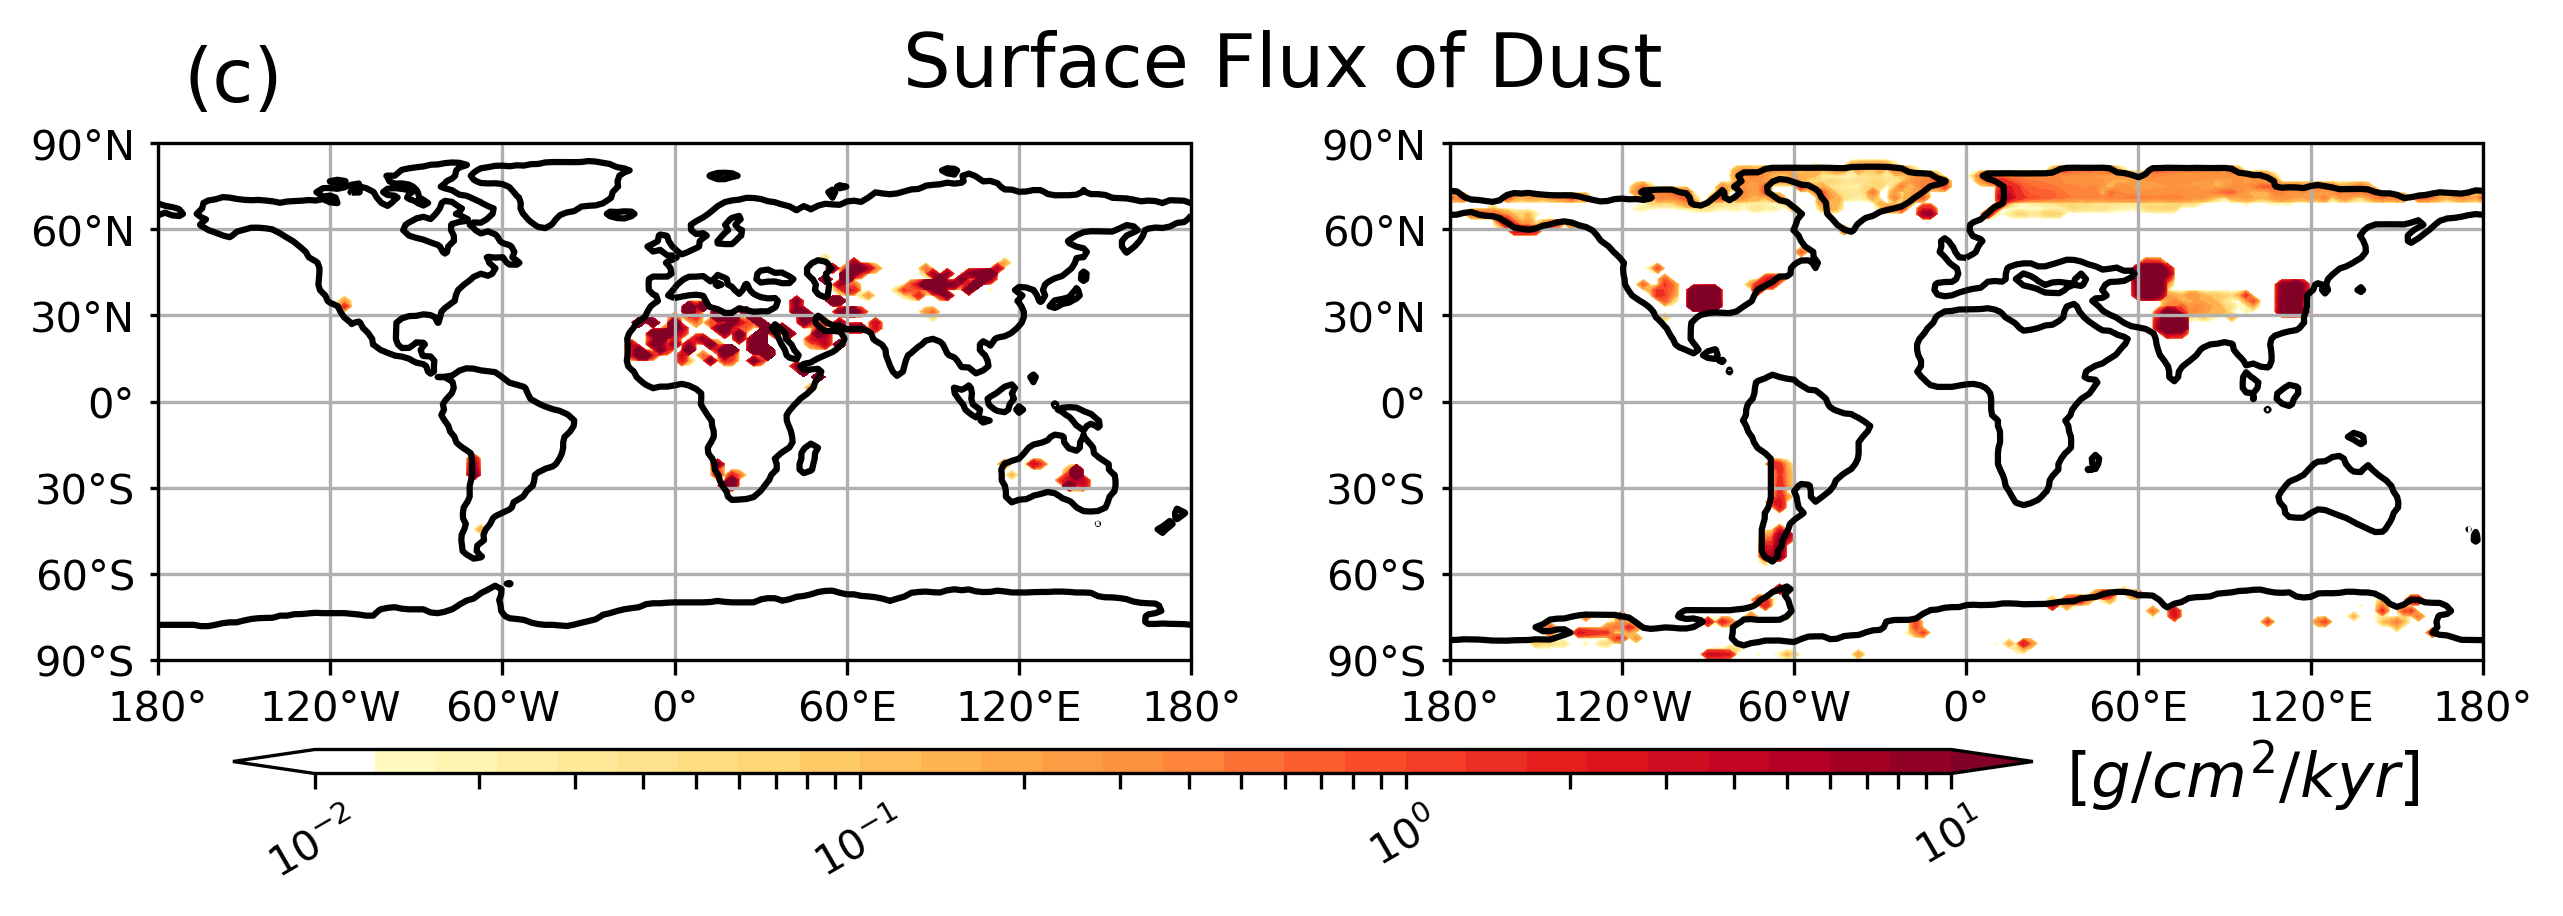

In [60]:
# set cmap for contourf

cmap = plt.cm.get_cmap('YlOrRd',len(levels))
colors = list(cmap(np.arange(len(levels))))
colors[0] = "white"                                # replace first color with white
cmap = mcolors.ListedColormap(colors[:-1], "")
cmap.set_over(colors[-1])                          # set over-color to last color of list 

levels = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
          0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
          1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
norm = mcolors.SymLogNorm(linthresh=0.01, vmin=0.01, vmax=10, base=10)
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)


# --- plot ---

data_title = 'Surface Flux of Dust'
plot_name = 'Fig1c_Dust_Sfc_Flux'

# Define the figure and each axis for the 1 rows and 2 columns
fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                        figsize=(10,8), dpi=300)
    
# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.25, hspace=0.35) 
    
# axs is a 2 dimensional array of `GeoAxes` --- flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(dst_SF['scenario']):
        
    # Contour plot
    if i==0:
        cs2 = axs[i].contourf(lons, lat, dst_SurfaceFlux[i,:,:], levels = levels, norm = norm,
                              transform = ccrs.PlateCarree(), cmap=cmap,extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5], transform = ccrs.PlateCarree(),
                       linestyles='solid', colors='k', linewidths=1.5, zorder=3)
    else:
        cs1 = axs[i].contourf(lons, lat, dst_SurfaceFlux[i,:,:], levels = levels, norm = norm,
                              transform = ccrs.PlateCarree(), cmap=cmap,extend='both')
        # Add coastines in Miocene Scenario
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],transform = ccrs.PlateCarree(),
                       linestyles='solid', colors='k', linewidths=1.5, zorder=3)     

    # Longitude labels
    axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()  
    axs[i].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
    axs[i].tick_params(axis='y', size=2)             # set xtick parameters
    for xlabel in axs[i].get_xticklabels():          # set xticks_label
        xlabel.set_fontsize(10)        

    # Latitude labels
    axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
    lat_formatter = cticker.LatitudeFormatter()
    axs[i].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
    axs[i].tick_params(axis='y', size=2)             # set ytick parameters
    for ylabel in axs[i].get_yticklabels():          # set yticks_label
        ylabel.set_fontsize(10)        
        
        
    # Title each subplot with the name of the month
    # axs[i].set_title(title[i])
          
    # Add gridlines
    axs[i].gridlines(colors='white', linewidths=0.2, zorder=2)
        
# Add colorbar
cax  = fig.add_axes([0.15, 0.34, 0.6, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB   = plt.colorbar(mappable, cax=cax, shrink=0.8, location='bottom', 
                    ticks=levels, extend='both', spacing='proportional', pad=0.05)
CB.ax.tick_params(rotation=30,labelsize=10)

plt.figtext(0.82,0.33,'[$g/cm^2/kyr$]',ha='center',fontsize=15)

plt.figtext(0.15,0.62,'(c)',ha='center',fontsize=18)

# Add title
plt.suptitle('Surface Flux of Dust', y=0.65, fontsize=18)
# fig.savefig(plot_name+'.png')
;